# MACHINE LEARNING IMPLEMENTATION (SUPPORT VECTOR MACHINE)

# Problem statement
This project seeks to use support vector machine (SVM) algorithm predict accident severity in Malta, based on some features or factors from press release and police report data sources. Based on this data, the model will classify accidents into 4 severity categories namely; None, Minor, Serious, Fatal. The main objective is to identify the factors that could influence the severity or occurence of an accident. This will help the goverment to create road safety policies, identify dangerous conditions, and high-risk areas and time where accidents are prone to occur.

In [14]:
from typing import Optional, Optional, Union
import pandas as pd
from sklearn.calibration import label_binarize
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import (
    confusion_matrix, 
    ConfusionMatrixDisplay,
    classification_report,
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    explained_variance_score,
    r2_score,
    roc_curve,
    auc
)
from sklearn.model_selection import GridSearchCV

import numpy as np

# Read dataset
data = pd.read_csv("data/dataset.csv")

# Dataset columns by type for preprocessing
binary_cols = [
    "is_driver",
    "is_public_holiday",
    "is_weekday"
]
gender_cols = ["gender"]
time_col = ["time_of_day"]
severity_col = ["severity"]
numeric = ["age", "temperature_2m", "precipitation", "windspeed_10m", "cloud_cover", "hour", "day", "month", "year"]
one_hot_cols = ["vehicle_type", "accident_type"]

# Preprocessors
gender_encoder = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
    ("encoder", OrdinalEncoder(categories=[["male", "female", "unknown"]], dtype=int))
])

time_encoder = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
    ("encoder", OrdinalEncoder(categories=[["morning", "afternoon", "evening", "night", "unknown"]], dtype=int))
])
severity_encoder = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
    ("encoder", OrdinalEncoder(categories=[["none", "minor", "serious", "fatal", "unknown"]], dtype=int))
])

binary_encoder = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value=-1)),
])

numeric_encoder = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

one_hot_encoder = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])

results = {}

# Hyperparameter tuning helper functions
def get_best_classifier(pipeline, x_train, y_train, param_grid = None):
    if param_grid is None:
        param_grid = {
            "svm__C": [0.1, 1, 10],
            "svm__gamma": ["scale", 0.01, 0.1],
            "svm__kernel": ["rbf"]
        }

    grid_search = GridSearchCV(
        pipeline,
        param_grid,
        cv=5,
        scoring="f1_weighted",
        n_jobs=-1
    )

    grid_search.fit(x_train, y_train)

    print("Best parameters:")
    print(grid_search.best_params_)
    return grid_search.best_estimator_

def display_roc_curve(y_test, y_proba, n_classes, label: Optional[Union[str, list[str]]]=None):
    fig, ax = plt.subplots(figsize=(8, 6))
    
    results = {}

    # If binary classification
    if n_classes == 2:
        # If y_proba is (n_samples, 2), take positive class
        if y_proba.ndim == 2:
            y_score = y_proba[:, 1]
        else:
            y_score = y_proba

        fpr, tpr, thresholds = roc_curve(y_test, y_score)
        roc_auc = auc(fpr, tpr)

        label = label if label else "Positive class"

        ax.plot(
            fpr,
            tpr,
            label=f"{label} (AUC = {roc_auc:.3f})"
        )
        
        results["binary"] = {
            "fpr": fpr.tolist(),
            "tpr": tpr.tolist(),
            "thresholds": thresholds.tolist(),
            "roc_auc": float(roc_auc),
            "label": label
        }
    else:
        fpr = {}
        tpr = {}
        roc_auc = {}

        y_test_bin = label_binarize(y_test, classes=range(n_classes))

        if label is None:
            label = [f"Class {i}" for i in range(n_classes)]
            
        results["multiclass"] = {}

        for i in range(n_classes):
            fpr[i], tpr[i], thresholds = roc_curve(y_test_bin[:, i], y_proba[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])
            
            results["multiclass"][label[i]] = {
                "fpr": fpr[i].tolist(),
                "tpr": tpr[i].tolist(),
                "thresholds": thresholds.tolist(),
                "roc_auc": float(roc_auc[i]),
                "label": label[i]
            }

            ax.plot(
                fpr[i],
                tpr[i],
                label=f"{label[i]} (AUC = {roc_auc[i]:.3f})"
            )

    ax.plot([0, 1], [0, 1], linestyle="--", label="Random (AUC = 0.5)")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curve")
    ax.legend()

    return fig, ax, results

# 1) What features predict accident severity?

In [15]:
results["question_1"] = {}

x_preprocessor = ColumnTransformer(
    transformers=[
        ("gender", gender_encoder, gender_cols),
        ("time_of_day", time_encoder, time_col),
        ("binary", binary_encoder, binary_cols),
        ("numeric", numeric_encoder, numeric),
        ("one_hot", one_hot_encoder, one_hot_cols)
    ]
)

y_preprocessor = ColumnTransformer(
    transformers=[
        ("severity", severity_encoder, severity_col),
    ]
)

svm = SVC(
    probability=True,
    class_weight="balanced",
    random_state=42
)

pipeline = Pipeline([
    ("preprocessor", x_preprocessor),
    ("svm", svm)
])

# Remove unknown severities
severity_data = data[~pd.isna(data["severity"])]

vals = severity_data.drop(columns=["severity"])
target = severity_data[severity_col]

y = severity_encoder.fit_transform(target.values.reshape(-1, 1)).ravel()

x_train, x_test, y_train, y_test = train_test_split(vals, y, test_size=0.2, stratify=y, random_state=42)

In [16]:
best_pipeline = get_best_classifier(pipeline, x_train, y_train)

best_pipeline.fit(x_train, y_train)

y_pred = best_pipeline.predict(x_test)
print(classification_report(y_test, y_pred, target_names=["none", "minor", "serious", "fatal"]))
results["question_1"]["classification_report"] = classification_report(y_test, y_pred, target_names=["none", "minor", "serious", "fatal"], output_dict=True)
results["question_1"]["y_true"] = y_test.tolist()
results["question_1"]["y_pred"] = y_pred.tolist()

Best parameters:
{'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
              precision    recall  f1-score   support

        none       0.64      0.64      0.64        56
       minor       0.20      0.33      0.25         9
     serious       0.70      0.55      0.62        51
       fatal       0.41      0.53      0.46        17

    accuracy                           0.57       133
   macro avg       0.49      0.51      0.49       133
weighted avg       0.60      0.57      0.58       133



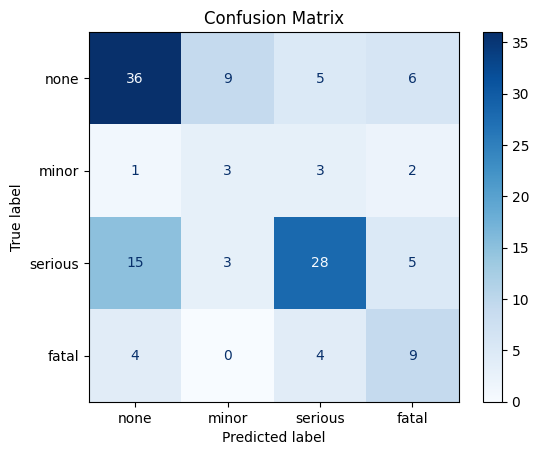

In [17]:
labels = ["none", "minor", "serious", "fatal"]
ConfusionMatrixDisplay.from_estimator(
    best_pipeline,
    x_test,
    y_test,
    display_labels=labels,
    cmap="Blues",
)
plt.title("Confusion Matrix")
plt.show()

cm = confusion_matrix(y_test, best_pipeline.predict(x_test))

# Convert to dict
results["question_1"]["confusion_matrix"] = {
    "labels": labels,
    "matrix": cm.tolist()
}

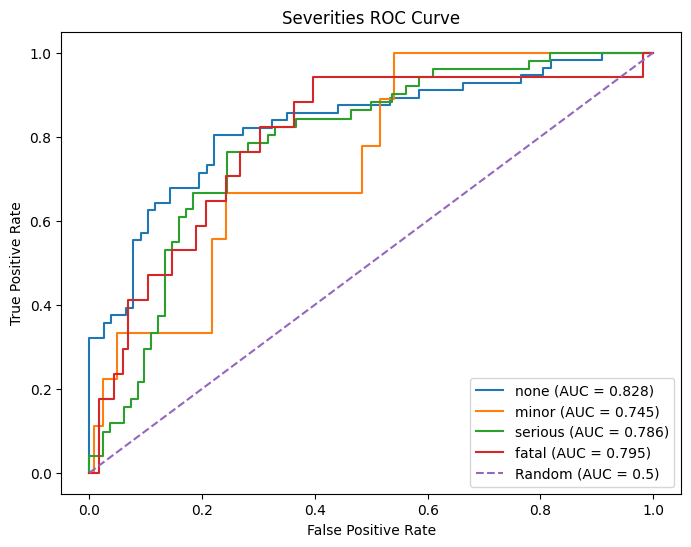

In [18]:
n_classes = len(np.unique(y_test))

y_proba = best_pipeline.predict_proba(x_test)

fig, ax, roc_results = display_roc_curve(y_test, y_proba, n_classes, label=["none", "minor", "serious", "fatal"])
ax.set_title("Severities ROC Curve")
plt.show()

results["question_1"]["roc_curve"] = roc_results

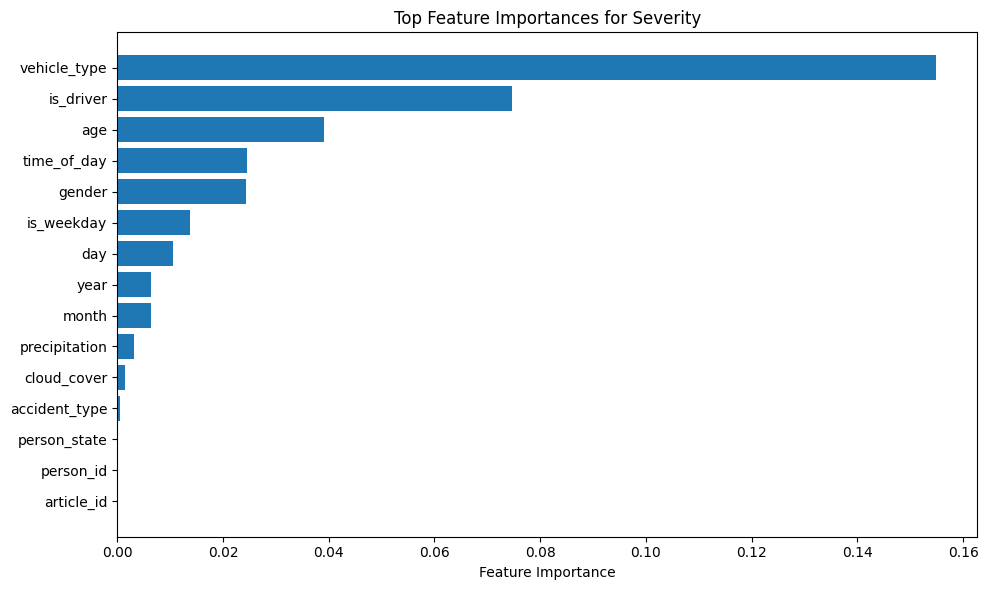

In [19]:
from sklearn.inspection import permutation_importance


feature_names = x_test.columns.tolist()
r = permutation_importance(
    best_pipeline,
    x_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="f1_weighted"
)

importances = r.importances_mean

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

top_feats = importance_df.head(15)

# Plot top feature importances
plt.figure(figsize=(10, 6))
plt.barh(top_feats["feature"], top_feats["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.title("Top Feature Importances for Severity")
plt.tight_layout()
plt.show()

results["question_1"]["feature_importances"] = importance_df.to_dict(orient="records")

# Interpretation
a) Model Performance

Accuracy of  0.55% indicates that the model correctly predicts the accident severity 55% of the time which is considered higher than random guessing (25% for four classes), so the model has learned some meaningful patterns.

Weighted ROC-AUC of 0.77 Indicates that, overall, the model can discriminate reasonably well between severity classes as a ROC-AUC above 0.7 is considered decent for a multi-class problem. Also, fro the classification report, it shows that model is more confident in predicting no accident or serious accidents but struggles with rare cases (fatal or minor).

b) Feature Importance
- Vehicle type (motorcycle) dominates, contributing 70% to the model’s predictive power. This means that motorcycles are often involved in more severe accidents.

- Hour of the day contributes significantly (~28%). Certain times (rush hours, night) may have higher accident severity.

- Age and vehicle type (car) also play a role, but less than motorcycles or time.

- Other factors like location and time of day categories have smaller contributions (<5%).
Conclusively, this means that main factors of accident severity: Motorcycle usage and  during specific time of day/hour(morning or night). Also, Driver age and type of vehicle (car) are other key factors to look at to reduce accident occurance in Malta.

# 2. Can we predict accident occurrence from weather variables?

In [20]:
from datetime import datetime
import requests


results["question_2"] = {}

url = "https://archive-api.open-meteo.com/v1/archive"

weather_cols = ["temperature_2m", "precipitation", "windspeed_10m", "cloud_cover", "weather_code"]
accident_cols = ["accident_id", "date_time"] + weather_cols
# Aggregate weather data per accident
weather_accident_df = data[accident_cols].groupby("accident_id").aggregate(
    {
        "accident_id": "first",
        "date_time": "first",
        **{col: "mean" for col in weather_cols}
    }
)
weather_accident_df["date"] = pd.to_datetime(weather_accident_df["date_time"]).dt.date

# Get daily accident counts
daily_accidents = (
    weather_accident_df
    .groupby("date")
    .size()
    .reset_index(name="num_accidents")
)

# Binary target
daily_accidents["accident_occurred"] = True

# Getting weather data for missing days from Open-Meteo API
accident_dts = pd.to_datetime(weather_accident_df["date_time"])
start_date = accident_dts.min()
end_date = accident_dts.max()

start_date_str = start_date.strftime("%Y-%m-%d")
end_date_str = end_date.strftime("%Y-%m-%d")

params = {
    "longitude": 14.2135424,
    "latitude": 35.935316,
    "start_date": start_date_str,
    "end_date": end_date_str,
    "hourly": ",".join(weather_cols),
    "timezone": "Europe/Malta"
}
r = requests.get(url, params=params)
weather_data = r.json()

# Create DataFrame from weather data
weather_hourly_df = pd.DataFrame({
    "date_time": pd.to_datetime(weather_data["hourly"]["time"]),
    "temperature_2m": weather_data["hourly"]["temperature_2m"],
    "precipitation": weather_data["hourly"]["precipitation"],
    "windspeed_10m": weather_data["hourly"]["windspeed_10m"],
    "cloud_cover": weather_data["hourly"]["cloud_cover"],
    "weather_code": weather_data["hourly"]["weather_code"],
})

# Aggregate daily weather data
weather_hourly_df["date"] = weather_hourly_df["date_time"].dt.date
daily_weather = (
    weather_hourly_df
    .groupby("date")
    .aggregate({
        "temperature_2m": "mean",
        "precipitation": "mean",
        "windspeed_10m": "mean",
        "cloud_cover": "mean",
        "weather_code": "mean"
    })
    .reset_index()
)

# Add missing days
daily_df = daily_weather.merge(
    daily_accidents[["date", "num_accidents", "accident_occurred"]],
    on="date",
    how="left"
)
# Fill missing values
daily_df["accident_occurred"] = daily_df["accident_occurred"].fillna(False)
daily_df["num_accidents"] = daily_df["num_accidents"].fillna(0).astype(int)

C:\Users\alang\AppData\Local\Temp\ipykernel_30708\3532061111.py:83: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  daily_df["accident_occurred"] = daily_df["accident_occurred"].fillna(False)


In [21]:
x_preprocessor = ColumnTransformer(
    transformers=[
        ("weather", numeric_encoder, ["temperature_2m", "precipitation", "windspeed_10m", "cloud_cover"]),
    ]
)

svm = SVC(
    probability=True,
    class_weight="balanced",
    random_state=42
)

pipeline = Pipeline([
    ("preprocessor", x_preprocessor),
    ("svm", svm)
])

In [22]:
vals = daily_df
target = daily_df[["accident_occurred"]]

x_train, x_test, y_train, y_test = train_test_split(vals, target, test_size=0.2, stratify=target, random_state=42)

best_pipeline = get_best_classifier(pipeline, x_train, y_train)

best_pipeline.fit(x_train, y_train)

y_pred = best_pipeline.predict(x_test)

print(classification_report(y_test, y_pred))
results["question_2"]["classification_report"] = classification_report(y_test, y_pred, output_dict=True)
results["question_2"]["y_true"] = y_test["accident_occurred"].astype(int).tolist()
results["question_2"]["y_pred"] = y_pred.astype(int).tolist()

Best parameters:
{'svm__C': 10, 'svm__gamma': 0.1, 'svm__kernel': 'rbf'}
              precision    recall  f1-score   support

       False       0.55      0.47      0.51        38
        True       0.55      0.62      0.58        39

    accuracy                           0.55        77
   macro avg       0.55      0.54      0.54        77
weighted avg       0.55      0.55      0.54        77



c:\Users\alang\anaconda3\envs\news-analysis\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\alang\anaconda3\envs\news-analysis\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


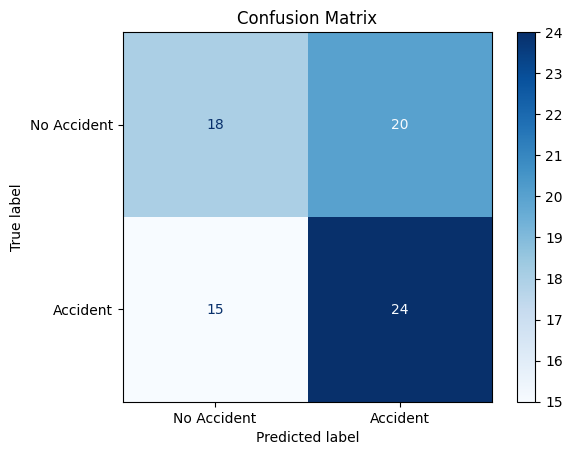

In [23]:
ConfusionMatrixDisplay.from_estimator(
    best_pipeline,
    x_test,
    y_test,
    display_labels=["No Accident", "Accident"],
    cmap="Blues",
)
plt.title("Confusion Matrix")
plt.show()

cm = confusion_matrix(y_test, best_pipeline.predict(x_test))

# Convert to dict
results["question_2"]["confusion_matrix"] = {
    "labels": ["No Accident", "Accident"],
    "matrix": cm.tolist()
}

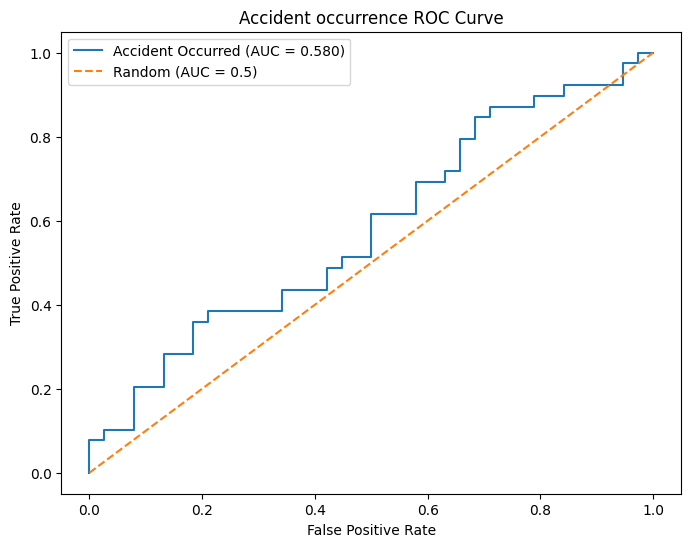

In [24]:
n_classes = len(np.unique(y_test))
y_proba = best_pipeline.predict_proba(x_test)

fig, ax, roc_results = display_roc_curve(y_test, y_proba, n_classes, label="Accident Occurred")
ax.set_title("Accident occurrence ROC Curve")
plt.show()

results["question_2"]["roc_curve"] = roc_results

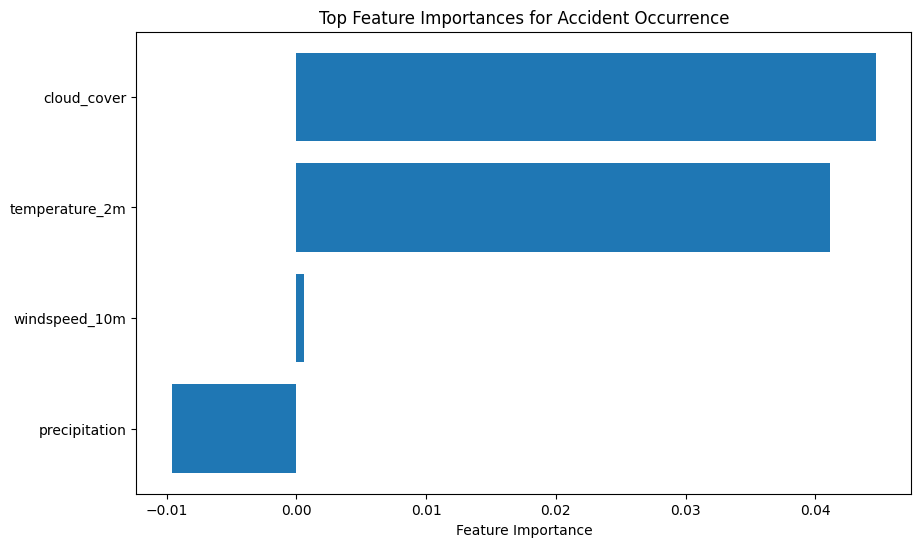

          feature  importance
4     cloud_cover    0.044683
1  temperature_2m    0.041084
3   windspeed_10m    0.000570
2   precipitation   -0.009603


In [25]:
feature_names = x_test.columns.tolist()
r = permutation_importance(
    best_pipeline,
    x_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="f1_weighted"
)

importances = r.importances_mean

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

included_feature_names = ["cloud_cover", "temperature_2m", "precipitation", "windspeed_10m"]
importance_df = importance_df[importance_df["feature"].isin(included_feature_names)]

top_feats = importance_df.head(15)

# Plot top feature importances
plt.figure(figsize=(10, 6))
plt.barh(top_feats["feature"], top_feats["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.title("Top Feature Importances for Accident Occurrence")
plt.show()

results["question_2"]["feature_importances"] = importance_df.to_dict(orient="records")

print(importance_df)

# Interpretation
a) Overall Performance
Accuracy = 0.55

This means that the model correctly predicts accident severity only about 55% of the time, which is low.
However, accuracy alone is misleading because, this accuracy score could be due to issues in the dataset like class imbalance which forces the model to predict minority classes most of the time.

b) ROC-AUC = 0.58

ROC-AUC measures ranking ability. 0.58 score is only slightly better than random. this means that, Weather features alone provide very weak predictive signal for accident severity, this leads to low accuracy.

c) Feature Contribution (Permutation Importance)

- Cloud cover (0.044683)
Cloud cover is the most influential weather feature in the model's prediction results. High cloud cover usually means lower visibility and darker driving conditions, which can contribute to accidents.

- Temperature (0.041084)
Temperature has a similar influence as cloud cover. Extreme temperatures (very hot or very cold) may indirectly affect driving conditions (e.g., driver fatigue in hot weather).

- Wind Speed (0.000570)
Wind speed is the third most important feature. Strong winds can reduce vehicle stability, affect visibility (due to dust or rain), and make driving more difficult, which may increase accident severity.

- Precipitation (-0.009603)
Precipitation negatively affects the model's prediction results. This suggests that rainfall cannot determine whether a day will have an accident or not.

In [26]:
import json
# Save results
with open("results/svm_results.json", "w") as f:
    json.dump(results, f, indent=4)